# ChatGPT labeling

In this notebook we will mark up generated data using ChatGPT API.

In [ ]:
# all data will be stored in data folder
!mkdir data

# upload CoLA data (in_domain_train.tsv)
!wget https://raw.githubusercontent.com/nyu-mll/CoLA-baselines/master/acceptability_corpus/raw/in_domain_train.tsv
# upload generated data (generated_data.csv)
!gdown 1iL5aYEk01vsv6GLbV_5Cs97Lzys1yhYb

!mv in_domain_train.tsv data/
!mv generated_data.csv data/

In [2]:
import openai
import pandas as pd
import time

from collections import Counter
from openai.error import RateLimitError
from sklearn.metrics import accuracy_score
from sklearn.utils import shuffle
from tqdm import tqdm

In [3]:
# load CoLA dataset
df_cola = pd.read_csv('data/in_domain_train.tsv', sep='\t', header=None)
df_cola = df_cola.drop(columns=[2]).rename(columns={0: 'id', 1: 'label', 3: 'text'})
df_cola = df_cola[['text', 'label', 'id']]

df_cola.head(3)

,text,label,id
0,"Our friends won't buy this analysis, let alone...",1,gj04
1,One more pseudo generalization and I'm giving up.,1,gj04
2,One more pseudo generalization or I'm giving up.,1,gj04


In [4]:
def create_balanced_sample(df, number_of_rows, label_value, random_state=13):
    sample_df_match = df[df['label'] == label_value].sample(
        n=(number_of_rows // 2), random_state=random_state)
    sample_df_unmatch = df[df['label'] != label_value].sample(
        n=(number_of_rows - number_of_rows // 2), random_state=random_state)
    sample_df = shuffle(pd.concat([sample_df_match, sample_df_unmatch],
                          axis=0, ignore_index=True))
    return sample_df

In [ ]:
# set up requests args
with open('api_key', 'r') as f:
    api_key = f.read().strip()

openai.api_key = api_key
openai_kwargs = {
    "model": "gpt-3.5-turbo",
    "temperature": 0,
    "max_tokens": 10,
}

In [121]:
def create_messages(text):
    return [
    {"role": "user", 
     "content": 'Score the following text with respect to ﬂuency with ' +\
     'either 0 or 1, where 0 means "disfluent" and 1 means "fluent". ' +\
     'Note that ﬂuency measures whether the text is well-written, ' +\
     'is grammatically correct, and does not look like AI-generated. ' +\
     'If the text contains at least one grammar mistake, then output 0. ' +\
     'Pay attention to correct usage of different tenses. ' +\
     'Output either 0 or 1.\n\n' +\
     f'Text:\n{text}\nScore: '}
]

In [ ]:
# Test prompt quality on small CoLA sample
chatgpt_scores = []
cola_sample = create_balanced_sample(df_cola, 30, 1)
texts = cola_sample['text'].to_list()
for text in tqdm(texts):
    openai_output = openai.ChatCompletion.create(
        **openai_kwargs, messages=create_messages(text))
    chatgpt_scores.append(openai_output["choices"][0]["message"]["content"].strip())

In [130]:
# Print scores accuracy 
accuracy = accuracy_score(
    list(map(int, chatgpt_scores)), cola_sample['label'].to_list())
print(f"CoLA prompt accuracy: {accuracy:.3f}")

CoLA prompt accuracy: 0.833


---

After experimenting with prompt it's time to add ChatGPT score to generated data.

In [6]:
# load generated dataset
df_gen = pd.read_csv('data/generated_data.csv')
df_gen.head(3)

,text,label,id
0,"addison had been working at a computer, and ma...",1,gen_0
1,addison corrected the errors when they were br...,1,gen_0
2,addison did this to be helpful for the class.,1,gen_0


In [136]:
# initialize variables
chatgpt_gen_scores = []
texts = df_gen['text'].to_list()
idx = 0

In [ ]:
# Collect ChatGPT scores, resume in 5 seconds in case of a rate limit error
# Indexes are saved in case of other errors
i = idx
while i < len(texts):
    try:
        openai_output = openai.ChatCompletion.create(
            **openai_kwargs, messages=create_messages(texts[i]))
        chatgpt_gen_scores.append(openai_output["choices"][0]["message"]["content"].strip())

        if i % 100 == 0:
            print(f'current step number: {i}')

        i += 1  
        idx += 1
    except RateLimitError as e:
        print("Encountered a rate limit error. Retrying in 5 seconds...")
        time.sleep(5)
        continue


In [148]:
# add chatgpt_label column and save table
df_gen['chatgpt_label'] = chatgpt_gen_scores
df_gen.to_csv(f'data/labeled_generated_data.csv', index=False)

---

Now let's create 2 new datasets:
* CoLA-E (CoLA Extended): with generated data for which ChatGPT labels matched generated labels
* CoLA-ECL (CoLA Extended with ChatGPT Labels): with all generated data with ChatGPT labels

In [ ]:
# if you need to download labeled_generated_data.csv file
!gdown 1txYNeceA8FMHqeqFiDAI4WwGfJ1dadhe
!mv labeled_generated_data.csv data/

In [10]:
# reload data with ChatGPT scores
df_gen = pd.read_csv('data/labeled_generated_data.csv')

In [17]:
# create first dataset
df_same_labels = df_gen[df_gen['chatgpt_label'] == df_gen['label']]
df_same_labels.drop(columns=['chatgpt_label']).to_csv(f'data/generated_cola_e.csv', index=False)

In [19]:
# create second dataset
df_chatgpt = df_gen.drop(columns=['label']).rename(columns={"chatgpt_label": "label"})
df_chatgpt.to_csv(f'data/generated_cola_ecl.csv', index=False)


In [39]:
# analyze labels balance
print(f"Labels in CoLA: 1 -- {Counter(df_cola['label'])[1]}, 0 -- {Counter(df_cola['label'])[0]} ")
print(f"ChatGPT labels in generated data: 1 -- {Counter(df_gen['chatgpt_label'])[1]}, 0 -- {Counter(df_gen['chatgpt_label'])[0]} ")
print(f"Generated labels in generated data: 1 -- {Counter(df_gen['label'])[1]}, 0 -- {Counter(df_gen['label'])[0]} ")
print(f"Labels where ChatGPT labels == Generated labels: 1 -- {Counter(df_same_labels['label'])[1]}, 0 -- {Counter(df_same_labels['label'])[0]} ")

Labels in CoLA: 1 -- 6023, 0 -- 2528 
ChatGPT labels in generated data: 1 -- 19417, 0 -- 8215 
Generated labels in generated data: 1 -- 13971, 0 -- 13661 
Labels where ChatGPT labels == Generated labels: 1 -- 10021, 0 -- 4265 


---

Now let's create some merged and balanced samples for fine-tuning.

In [26]:
# this file contains CoLA dataset merged with generated data, filtered by ChatGPT scores of fluency
# (if generated label matched ChatGPT label, we added sample to dataset)
# We added all negative samples and 2k of positive ones, to make data more balanced
ones_to_add = 2000
df_gen_filtered = pd.read_csv('data/generated_cola_e.csv')
df_gen_filt_sample = pd.concat(
    [
        df_gen_filtered[df_gen_filtered['label'] == 0],
        df_gen_filtered[df_gen_filtered['label'] == 1][:ones_to_add]
    ]).reset_index(drop=True)

df_merged = pd.concat([df_gen_filt_sample, df_cola]).reset_index(drop=True)
df_merged.to_csv(f'data/cola_e_balanced.csv', index=False)

print(Counter(df_merged['label']))

Counter({1: 8023, 0: 6793})


In [27]:
# This file contains CoLA dataset merged with generated data, labeled by ChatGPT scores of fluency
# (If generated label did not match ChatGPT label, we changed label)
# We added all negative samples and 4k of positive ones, to make data more balanced
ones_to_add = 4000
df_gen_chatgpt = pd.read_csv('data/generated_cola_ecl.csv')
df_gen_chatgpt_sample = pd.concat(
    [
        df_gen_chatgpt[df_gen_chatgpt['label'] == 0],
        df_gen_chatgpt[df_gen_chatgpt['label'] == 1][:ones_to_add]
    ]).reset_index(drop=True)

df_merged_chatgpt = pd.concat([df_gen_chatgpt_sample, df_cola]).reset_index(drop=True)
df_merged_chatgpt.to_csv(f'data/cola_ecl_balanced.csv', index=False)

print(Counter(df_merged_chatgpt['label']))

Counter({0: 10743, 1: 10023})


---

Here we create the visualizations of class balance.

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

sns.set_style("darkgrid")

plt.rcParams['font.size'] = 12

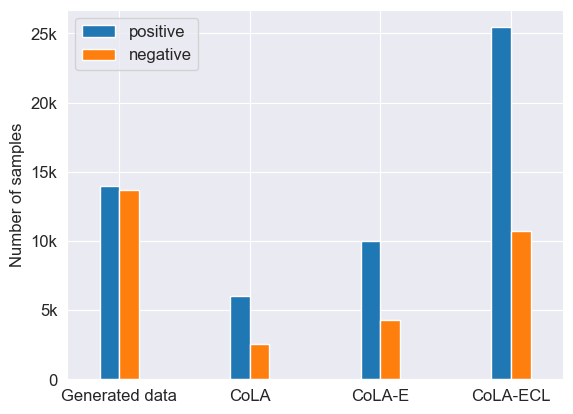

In [23]:
cola_e = pd.concat([df_same_labels, df_cola]).reset_index(drop=True)
cola_ecl = pd.concat([df_chatgpt, df_cola]).reset_index(drop=True)

datasets = [df_gen, df_cola, df_gen_filtered, cola_ecl]
index = ['Generated data', 'CoLA', 'CoLA-E', 'CoLA-ECL']

positive = [Counter(dataset['label'])[1] for dataset in datasets]
negative = [Counter(dataset['label'])[0] for dataset in datasets]

df = pd.DataFrame({'positive': positive,
                   'negative': negative}, index=index)
ax = df.plot.bar(rot=0, width=0.3, ylabel='Number of samples', yticks=[0, 5000, 10000, 15000, 20000, 25000])
ax.set_yticklabels(["0", "5k", "10k", "15k", "20k", "25k"])

fig = ax.get_figure()
fig.savefig('data/data_balance.png', dpi=300)

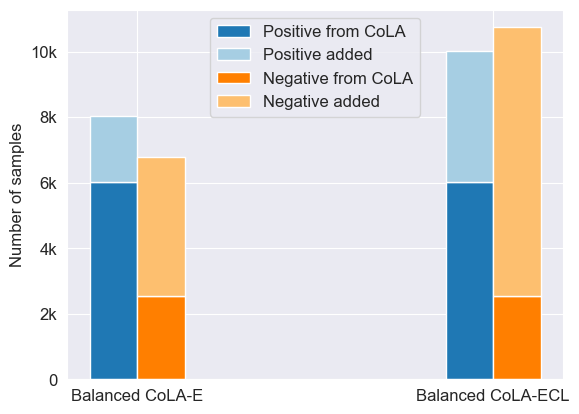

In [25]:
datasets = [df_merged, df_merged, df_merged_chatgpt, df_merged_chatgpt]
labels = [1, 0, 1, 0]

count_cola = [Counter(df_cola['label'])[idx] for idx in labels]
added_data = [Counter(datasets[i]['label'])[labels[i]] - count_cola[i] for i in range(4)]

# Example data
data = {
    'Category': ['Balanced CoLA-E', 'Balaced CoLA-ECL'],
    'Positive from CoLA': [count_cola[0], count_cola[2]],
    'Positive added': [added_data[0], added_data[2]],
    'Negative from CoLA': [count_cola[1], count_cola[3]],
    'Negative added': [added_data[1], added_data[3]]
}

df = pd.DataFrame(data)

# Define the categories and column pairs
categories = ['Balanced CoLA-E', 'Balanced CoLA-ECL']
column_pairs = [('Positive from CoLA', 'Positive added'), ('Negative from CoLA', 'Negative added')]

# Calculate the width of each bar
bar_width = 0.05
index = np.arange(len(categories))

palette = sns.color_palette("Paired")
colors = [[palette[1], palette[0]], [palette[7], palette[6]]]

# Plotting the stacked bar plot
fig, ax = plt.subplots()
for i, pair in enumerate(column_pairs):
    bars = ax.bar(index + (i * bar_width) - index / 1.6, df[pair[0]], bar_width, label=pair[0], color=colors[i][0])
    bars = ax.bar(index + (i * bar_width)- index / 1.6, df[pair[1]], bar_width, bottom=df[pair[0]], label=pair[1], color=colors[i][1])

# Set the x-axis tick labels
ax.set_xticks((index + bar_width / 2) - index / 1.6)
ax.set_xticklabels(categories)
ax.set_ylabel('Number of samples')
ax.set_yticks([0, 2000, 4000, 6000, 8000, 10000])
ax.set_yticklabels(["0", "2k", "4k", "6k", "8k", "10k"])

# Add a legend
ax.legend(loc=9)

plt.show()

fig = ax.get_figure()
fig.savefig('data/data_balance_stacked.png', dpi=300)
